<a href="https://colab.research.google.com/github/IMPERIUMSIXTH/JupyterNotebooks/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install celluloid scienceplots

# import numpy as np
import autograd.numpy as np
from autograd import grad
from autograd import elementwise_grad as egrad

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sklearn.datasets as skdatasets

from celluloid import Camera
import scienceplots
from IPython.display import Image

np.random.seed(0)
plt.style.use(["science", "no-latex"])

Text(0.5, 1.0, 'Synthetic Classification Dataset')

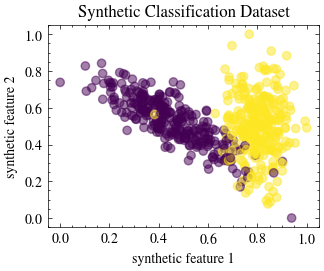

In [4]:
# Generate a synthetic dataset instead of loading one
X, Y = skdatasets.make_classification(
    n_samples=569,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)
feature_names = ["synthetic feature 1", "synthetic feature 2"]
target_names = ["malignant", "benign"]

# min-max normalize the features along the columns
X_min_vals = X.min(axis=0)
X_max_vals = X.max(axis=0)
X = (X - X_min_vals) / (X_max_vals - X_min_vals)

fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(X[:, 0], X[:, 1], c=Y, alpha=0.5)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_title("Synthetic Classification Dataset")

In [5]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))

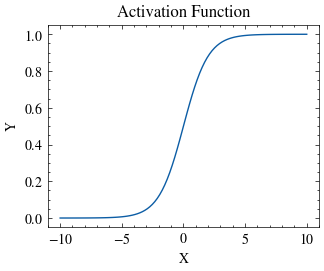

In [6]:
def plot(fx, x_min, x_max, points=100, title=""):

    x = np.linspace(x_min, x_max, points)
    y = fx(x)

    fig, axes = plt.subplots()
    axes.plot(x, y)
    axes.set_xlabel("X")
    axes.set_ylabel("Y")
    axes.set_title("Activation Function")


x_min = -10
x_max = 10
points = 100
plot(sigmoid, x_min, x_max, points)

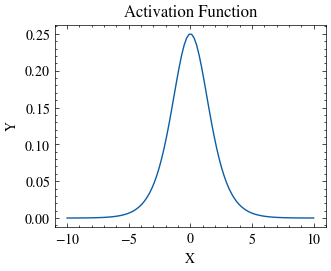

In [7]:
sigmoid_prime = lambda x: np.exp(-x) / np.power((1 + np.exp(-x)), 2)
plot(sigmoid_prime, x_min, x_max, points)

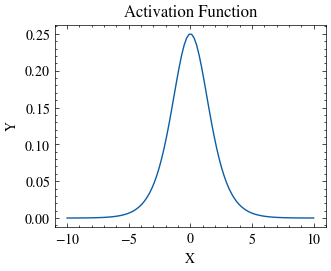

In [8]:
# grad() differentiates scalar inputs
sigmoid_prime_grad = grad(sigmoid)
# egrad() differentiates vectorized inputs
sigmoid_prime_egrad = egrad(sigmoid)

x = np.linspace(x_min, x_max, points)
assert sigmoid_prime_grad(x[0]) == sigmoid_prime(x[0])
assert np.allclose(sigmoid_prime_egrad(x), sigmoid_prime(x))

plot(sigmoid_prime_egrad, x_min, x_max, points)

In [9]:
def bce(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [10]:
def bce_dw(x, y_true, y_pred):
    return np.mean(x * (y_pred - y_true))

In [11]:
def bce_db(y_true, y_pred):
    return np.mean(y_pred - y_true)

In [12]:
def gradient_descent(weights, x, bias, y_true, y_pred, learning_rate):
    weights = weights - learning_rate * bce_dw(x, y_true, y_pred)
    bias = bias - learning_rate * bce_db(y_true, y_pred)

    return weights, bias

In [13]:
def create_plots():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1))
    fig.suptitle("Logistic Regression")

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Error", fontweight="normal")
    ax[0].set_title("Binary Cross Entropy Error")

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Prediction Probabilities")
    ax[2].view_init(20, -35)

    camera = Camera(fig)
    return ax[0], ax[2], camera


def plot_graphs(
    ax0,
    ax1,
    idx,
    visible_mse,
    mse_idx,
    errors,
    features,
    labels,
    predictions,
    points_x,
    points_y,
    surface_predictions,
):
    ax0.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )

    # Plot Logistic Regression Predictions
    # Ground truth and training data
    ground_truth_legend = ax1.scatter(
        features[:, 0],
        features[:, 1],
        labels,
        color="red",
        alpha=0.5,
        label="Ground Truth",
    )
    # Logistic Regression Predictions
    predictions_legend = ax1.scatter(
        features[:, 0],
        features[:, 1],
        predictions,
        color="blue",
        alpha=0.2,
        label="Prediction",
    )
    ax1.plot_surface(
        points_x,
        points_y,
        surface_predictions.reshape(dims, dims),
        color="blue",
        alpha=0.2,
    )
    ax1.legend(
        (ground_truth_legend, predictions_legend),
        ("Ground Truth", "Predictions"),
        loc="upper left",
    )

In [14]:
def fit(
    w0, b0, features, labels, dims, epochs, learning_rate, optimizer, output_filename
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    ax0, ax1, camera = create_plots()

    points = np.linspace(0, 1, dims)
    points_x, points_y = np.meshgrid(points, points)
    surface_points = np.column_stack((points_x.flatten(), points_y.flatten()))

    weights = w0
    bias = b0

    for idx in range(epochs):
        error = 0
        predictions = np.array([])
        surface_predictions = np.array([])

        # fit the model on the training data
        for x, y in zip(features, labels):
            output = sigmoid(np.dot(weights, x) + bias)

            predictions = np.append(predictions, output)

            # Store Error
            error += bce(y, output)

            # Gradient Descent
            weights, bias = optimizer(weights, x, bias, y, output, learning_rate)

        # error /= len(features)

        # Visualization
        if (
            idx < 5
            or (idx < 15 and idx % 5 == 0)
            or (idx <= 50 and idx % 25 == 0)
            or (idx <= 1000 and idx % 200 == 0)
            or idx % 500 == 0
        ):
            for surface_point in surface_points:
                output = sigmoid(np.dot(weights, surface_point) + bias)
                surface_predictions = np.append(surface_predictions, output)

            print(f"epoch: {idx:>4}, BCA: {round(error, 2)}")

            # Plot BCE
            errors[idx] = error
            visible_mse = errors != -1

            plot_graphs(
                ax0,
                ax1,
                idx,
                visible_mse,
                mse_idx,
                errors,
                features,
                labels,
                predictions,
                points_x,
                points_y,
                surface_predictions,
            )

            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")

epoch:    0, BCA: 476.38
epoch:    1, BCA: 460.66
epoch:    2, BCA: 447.38
epoch:    3, BCA: 436.23
epoch:    4, BCA: 426.96
epoch:    5, BCA: 419.27
epoch:   10, BCA: 397.11
epoch:   25, BCA: 382.89
epoch:   50, BCA: 375.5
epoch:  200, BCA: 339.4
epoch:  400, BCA: 304.17
epoch:  500, BCA: 290.51
epoch:  600, BCA: 278.81
epoch:  800, BCA: 259.92
epoch: 1000, BCA: 245.42
epoch: 1500, BCA: 220.83
epoch: 2000, BCA: 205.6
epoch: 2500, BCA: 195.35
epoch: 3000, BCA: 188.03
epoch: 3500, BCA: 182.58
epoch: 4000, BCA: 178.39
epoch: 4500, BCA: 175.09
epoch: 5000, BCA: 172.43


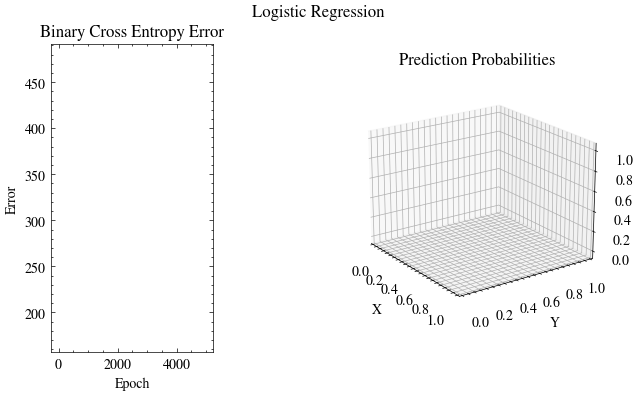

In [15]:
epochs = 5001
learning_rate = 0.0005
dims = 10

w0 = np.random.rand(X[0].shape[0])
b0 = np.random.rand()

output_filename = "logistic_regression.gif"
fit(w0, b0, X, Y, dims, epochs, learning_rate, gradient_descent, output_filename)

In [ ]:
Image(filename=output_filename)